In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "TomatoBlight",
    seed=123,
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 16011 files belonging to 10 classes.


In [4]:
class_names=dataset.class_names
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [5]:
len(dataset)

501

In [6]:
501*32

16032

In [7]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())

(32, 256, 256, 3)
[0 2 4 6 0 7 9 6 6 7 4 7 1 1 0 7 0 7 0 9 0 5 7 2 1 4 7 9 9 1 2 5]


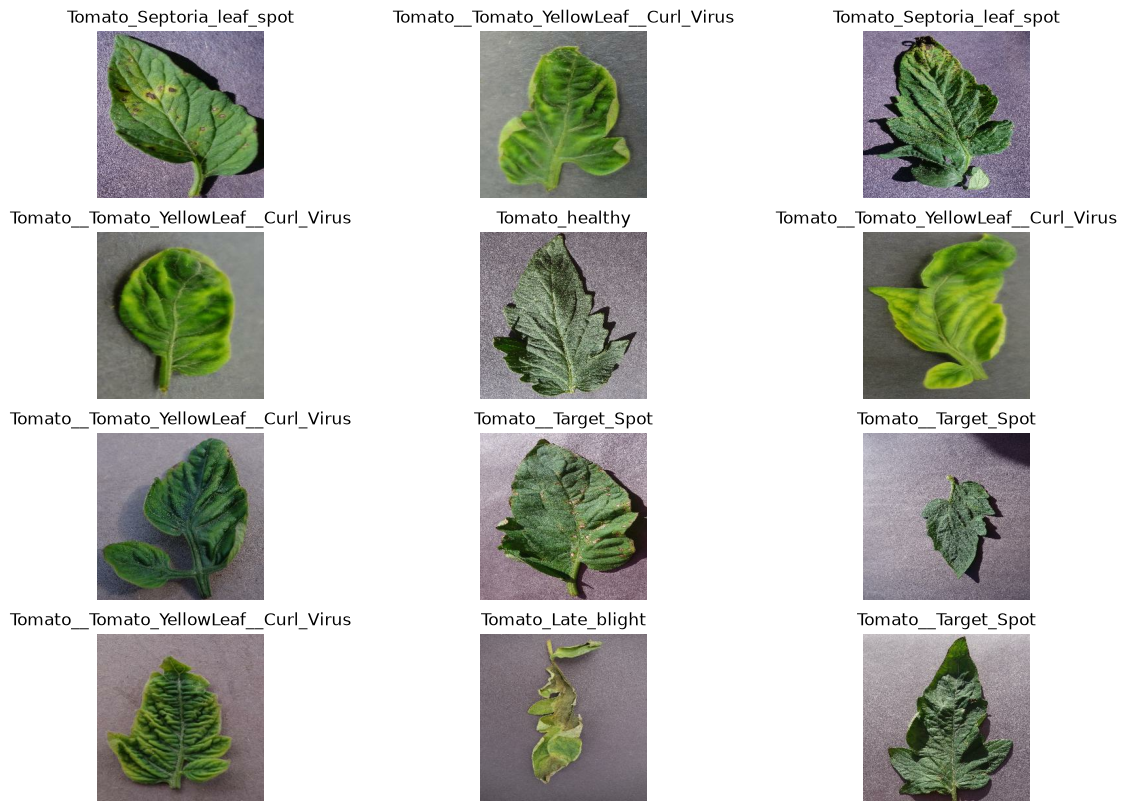

In [8]:
plt.figure(figsize=(14,10))
for image_batch, labels_batch in dataset.take(1):
    for i in range(12):
        plt.subplot(4,3,i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(class_names[labels_batch[i]])
        plt.axis('off')

In [ ]:
80% ====> traning
20% ====> 10% validation, 10% test

In [9]:
ds_size=len(dataset)
ds_size

501

In [10]:
train_size=0.8
len(dataset)*train_size

400.8

In [11]:
train_ds=dataset.take(400)
len(train_ds)

400

In [12]:
test_ds=dataset.skip(400)
len(test_ds)

101

In [13]:
val_size=0.1
len(dataset)*val_size

50.1

In [14]:
val_ds=test_ds.take(50)
len(val_ds)

50

In [15]:
test_ds=test_ds.skip(50)
len(test_ds)

51

In [16]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=ds_size):
    assert (train_split + test_split + val_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds,  val_ds, test_ds
        

In [17]:
train_ds,val_ds,test_ds =  get_dataset_partitions_tf(dataset)

In [18]:
len(train_ds)

400

In [19]:
len(val_ds)

50

In [20]:
len(test_ds)

51

In [21]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [22]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1./255),
])

In [23]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [24]:
input_shape = (IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes = 10

model =models.Sequential([
    layers.Input(shape=input_shape),
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

In [25]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,202 (719.54 KB)

 Trainable params: 184,202 (719.54 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [27]:
history=model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    verbose=1
)

Epoch 1/50


/opt/anaconda3/envs/ds/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1785923748.898734 7436374 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 375 of 501
I0000 00:00:1785923759.779040 7436374 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 446 of 501
I0000 00:00:1785923767.522367 7436374 shuffle_dataset_op.cc:483] Shuffle buffer filled.


400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.4148 - loss: 1.6501

I0000 00:00:1785924060.379071 7440051 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 414 of 501
I0000 00:00:1785924070.332873 7440051 shuffle_dataset_op.cc:483] Shuffle buffer filled.


400/400 ━━━━━━━━━━━━━━━━━━━━ 348s 784ms/step - accuracy: 0.4148 - loss: 1.6501 - val_accuracy: 0.5119 - val_loss: 1.4506
Epoch 2/50


...

400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.9741 - loss: 0.0723

I0000 00:00:1785941552.835054 7688111 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 494 of 501
I0000 00:00:1785941553.007800 7688111 shuffle_dataset_op.cc:483] Shuffle buffer filled.


400/400 ━━━━━━━━━━━━━━━━━━━━ 324s 771ms/step - accuracy: 0.9741 - loss: 0.0723 - val_accuracy: 0.9675 - val_loss: 0.0954
Epoch 50/50


I0000 00:00:1785941578.114692 7688743 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 409 of 501
I0000 00:00:1785941588.986030 7688743 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 480 of 501
I0000 00:00:1785941589.720330 7688743 shuffle_dataset_op.cc:483] Shuffle buffer filled.


400/400 ━━━━━━━━━━━━━━━━━━━━ 323s 748ms/step - accuracy: 0.9691 - loss: 0.0901 - val_accuracy: 0.9690 - val_loss: 0.0740


In [28]:
scores=model.evaluate(test_ds)

I0000 00:00:1785941901.278945 7693831 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 447 of 501
I0000 00:00:1785941909.154989 7693831 shuffle_dataset_op.cc:483] Shuffle buffer filled.


51/51 ━━━━━━━━━━━━━━━━━━━━ 32s 260ms/step - accuracy: 0.9628 - loss: 0.0917


In [29]:
history

In [30]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 400}

In [31]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [32]:
acc=history.history['accuracy']
loss=history.history['loss']
val_acc=history.history['val_accuracy']
val_loss=history.history['val_loss']

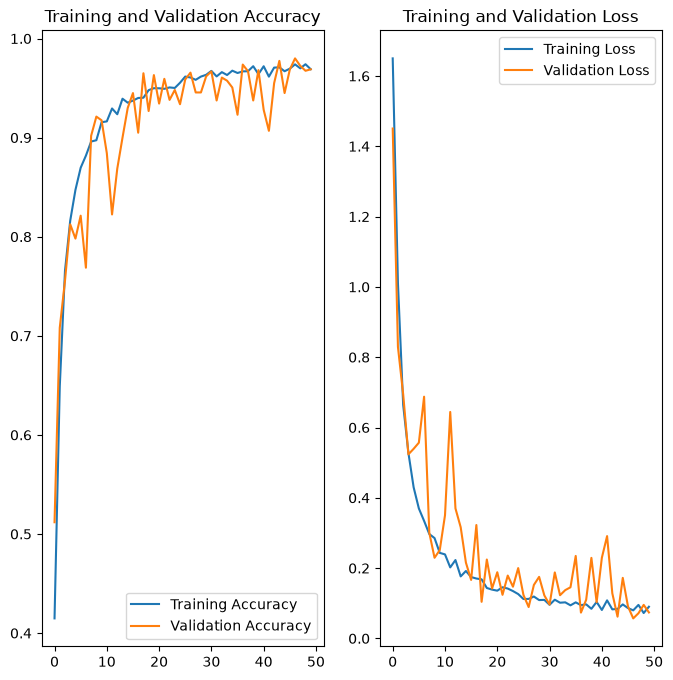

In [33]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [34]:
import numpy as np

I0000 00:00:1785941972.145101 7695318 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 429 of 501
I0000 00:00:1785941975.817726 7695318 shuffle_dataset_op.cc:483] Shuffle buffer filled.


first image to predict
actual label: Tomato_healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
predicted label: Tomato_healthy


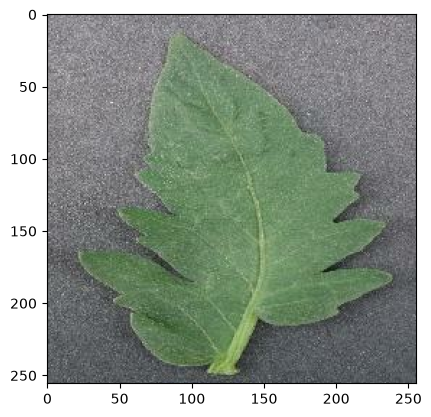

In [35]:
 for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [36]:
def predict(model, img):
    img = tf.expand_dims(img, axis=0)
    prediction = model.predict(img, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = round(np.max(prediction) * 100, 2)

    return predicted_class, confidence

I0000 00:00:1785941998.319373 7695919 shuffle_dataset_op.cc:453] ShuffleDatasetV3:13: Filling up shuffle buffer (this may take a while): 496 of 501
I0000 00:00:1785941998.677451 7695919 shuffle_dataset_op.cc:483] Shuffle buffer filled.


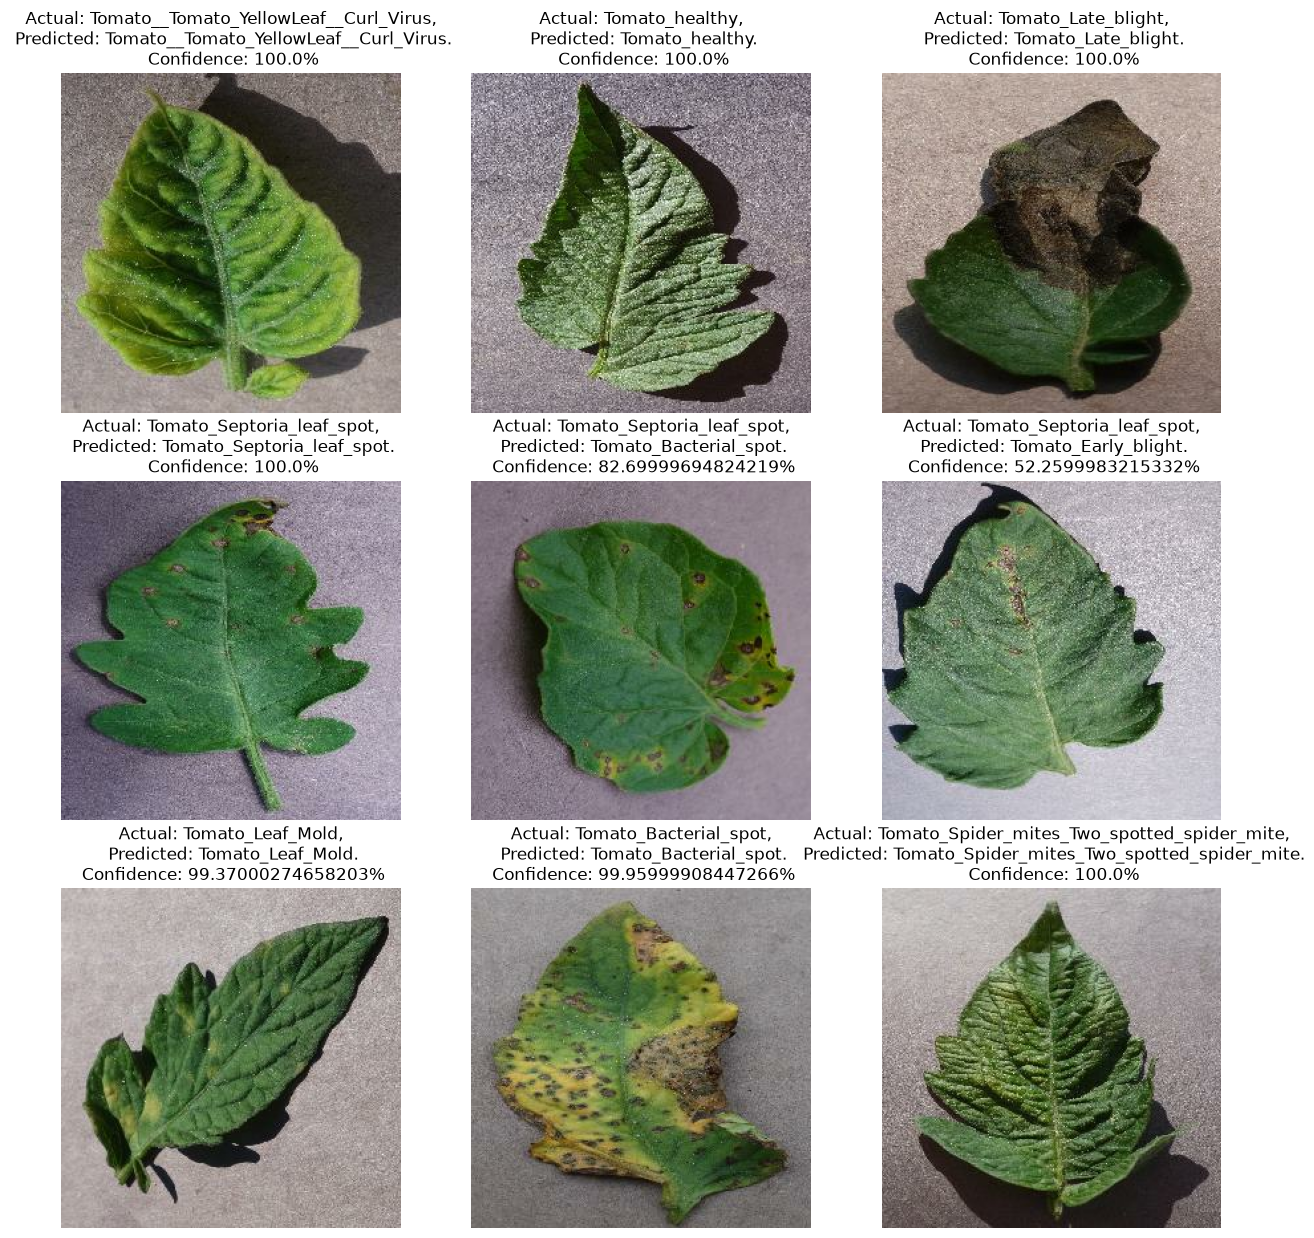

In [37]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [38]:
import os

os.makedirs("models", exist_ok=True)

versions = os.listdir("models")
model_version = len(versions) + 1

model.save(f"models/{model_version}.keras")

print(f"Model saved as models/{model_version}.keras")

Model saved as models/1.keras
